# Driving log file explained
CSV file contains 7 columns.\
There are 3 cameras mounted on the car (center, left, right)\
\
Column 1: Path to image captured by center camera\
Column 2: Path to image captured by left camera\
Column 3: Path to image captured by right camera\
Column 4: Steering input\
Column 5: Throttle input (0-1)\
Column 6: Brake input (0 OR 1)\
Column 7: Speed in KM/h

In [10]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


cols = ['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
raw_df = pd.read_csv('driving_log.csv', header=None, names=cols)

df = raw_df.select_dtypes(include=['number'])

df.info()
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2617 entries, 0 to 2616
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   steering  2617 non-null   float64
 1   throttle  2617 non-null   float64
 2   brake     2617 non-null   int64  
 3   speed     2617 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 81.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2617 entries, 0 to 2616
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   center    2617 non-null   object 
 1   left      2617 non-null   object 
 2   right     2617 non-null   object 
 3   steering  2617 non-null   float64
 4   throttle  2617 non-null   float64
 5   brake     2617 non-null   int64  
 6   speed     2617 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 143.2+ KB


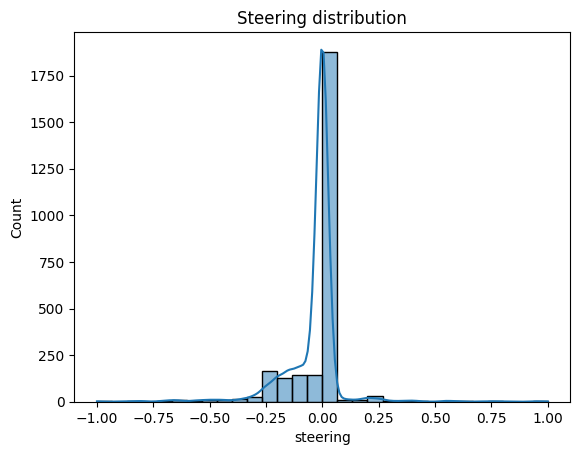

In [ ]:
# steering only
sns.histplot(df["steering"], bins=30, kde=True)
plt.xlabel('steering')
plt.title('Steering distribution')
plt.show()

In [32]:
speed_max = df["speed"].max()
speed_max

np.float64(30.63811)

In [36]:
speed_min = df["speed"][df["speed"] > 4].min()
speed_min

np.float64(4.231659)

In [37]:
bins = range(0, int(df["speed"].max()) + 2)
counts = pd.cut(df["speed"], bins=bins, right=False).value_counts().sort_index()
counts


speed
[0, 1)        16
[1, 2)         2
[2, 3)         1
[3, 4)         1
[4, 5)         2
[5, 6)         1
[6, 7)         1
[7, 8)         1
[8, 9)         1
[9, 10)        2
[10, 11)       1
[11, 12)       2
[12, 13)       1
[13, 14)       1
[14, 15)       2
[15, 16)       1
[16, 17)       2
[17, 18)       1
[18, 19)       1
[19, 20)       2
[20, 21)       1
[21, 22)       2
[22, 23)       2
[23, 24)       1
[24, 25)       2
[25, 26)       2
[26, 27)       1
[27, 28)       2
[28, 29)       2
[29, 30)       4
[30, 31)    2556
Name: count, dtype: int64

<Axes: xlabel='speed', ylabel='Count'>

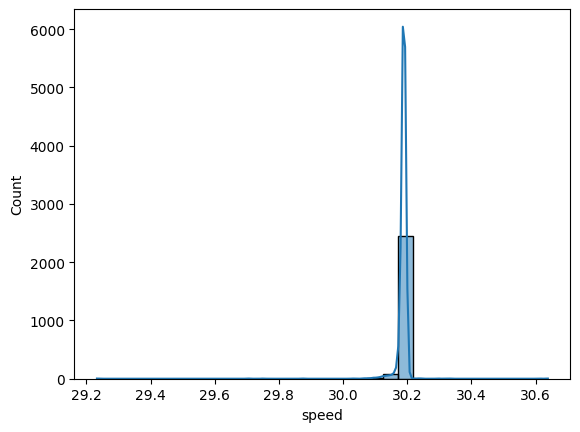

In [30]:
speed_max = df["speed"].max()
sns.histplot(
    df.loc[df["speed"].between(29, speed_max), "speed"],
    bins=30,
    kde=True,
)
